In [1]:
import pandas as pd
df = pd.read_csv("train.csv")

print(df.shape)

(891, 12)


Сколько строк и столбцов

In [2]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Какие типы данных в каждом столбце

In [3]:
print(df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

Первые 10 строк

In [4]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Статистика числовых столбцов

In [5]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Сколько пропусков в каждом столбце

In [6]:
survived = df[df["Survived"] == 1]
print(len(survived))
print(342 / 891 * 100)

342
38.38383838383838


342 человека выжило, что составляет примерно 38,43% от всех людей на борту

In [7]:
women = df[df["Sex"] == "female"]
print(len(women))

314


На борту 314 женщин

In [8]:
first_old = df[(df["Pclass"] == 1) & (df["Age"] > 40)]
print(len(first_old))

76


Вместо and мы используем (условие) & (условие), т.к. df["Pclass"] == 1 и df["Age"] > 40 возвращает Pd.Series булевых значений, \
а оператор and работает со сравнениями булевых значений по одному, а не с серией сразу. 
Также вместо or мы используем |, а вместо not ~.

In [9]:
women_dead = df[(df["Sex"] == "female") & (df["Survived"] == 0)]
print(len(women_dead))
print(81 / 314 * 100)

81
25.796178343949045


Всего погибла 81 женщина, что составляет примерно 25,8% от общего числа женщин.

In [10]:
no_age = df[df["Age"].isnull()]
print(len(no_age))

177


При анализе данных мы не можем учесть этих людей по возрастным критериям, сл. будем либо не брать их в расчёт.

In [11]:
print(df.loc[0:5, "Name" : "Age"])

                                                Name     Sex   Age
0                            Braund, Mr. Owen Harris    male  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0
2                             Heikkinen, Miss. Laina  female  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0
4                           Allen, Mr. William Henry    male  35.0
5                                   Moran, Mr. James    male   NaN


Выводим первые от 0 до 5(вкл.) строк от Name до Age столбцов. # loc — по меткам (названиям)
loc включает правую границу
loc['Name':'Age'] - включает обе колонки (Name, Sex, Age)

In [12]:
print(df.iloc[0:5, 0:4])

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  
0                            Braund, Mr. Owen Harris  
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  
2                             Heikkinen, Miss. Laina  
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  
4                           Allen, Mr. William Henry  


iloc — по номерам позиций (как индекс массива)
Даёт 6 строк первых 4-х стоблцов (по индексам)
iloc исключает правую границу (5 не включается)
Работает как стандартный Python-срез: start:stop исключает stop
iloc[0:4] - берет колонки с позициями 0, 1, 2, 3 (первые 4 колонки)

In [13]:
# Возьми строки 10-20, столбцы Name и Survived — через loc
df.loc[10:20, ['Name', 'Survived']]

,Name,Survived
10,"Sandstrom, Miss. Marguerite Rut",1
11,"Bonnell, Miss. Elizabeth",1
12,"Saundercock, Mr. William Henry",0
13,"Andersson, Mr. Anders Johan",0
14,"Vestrom, Miss. Hulda Amanda Adolfina",0
15,"Hewlett, Mrs. (Mary D Kingcome)",1
16,"Rice, Master. Eugene",0
17,"Williams, Mr. Charles Eugene",1
18,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",0
19,"Masselmani, Mrs. Fatima",1


In [14]:
# То же самое через iloc
df.iloc[10:21, [3, 1]]

,Name,Survived
10,"Sandstrom, Miss. Marguerite Rut",1
11,"Bonnell, Miss. Elizabeth",1
12,"Saundercock, Mr. William Henry",0
13,"Andersson, Mr. Anders Johan",0
14,"Vestrom, Miss. Hulda Amanda Adolfina",0
15,"Hewlett, Mrs. (Mary D Kingcome)",1
16,"Rice, Master. Eugene",0
17,"Williams, Mr. Charles Eugene",1
18,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",0
19,"Masselmani, Mrs. Fatima",1


In [15]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Самый популярный порт - порт S

In [16]:
df["Pclass"].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

В 3-м классе больше всего пассажиров

In [17]:
df[["Name", "Fare", "Pclass"]].sort_values("Fare", ascending=False).head(10)

,Name,Fare,Pclass
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1
258,"Ward, Miss. Anna",512.3292,1
737,"Lesurer, Mr. Gustave J",512.3292,1
88,"Fortune, Miss. Mabel Helen",263.0000,1
438,"Fortune, Mr. Mark",263.0000,1
341,"Fortune, Miss. Alice Elizabeth",263.0000,1
27,"Fortune, Mr. Charles Alexander",263.0000,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",262.3750,1
311,"Ryerson, Miss. Emily Borie",262.3750,1
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",247.5208,1


У всех пассажиров с дорогими билетами 1-ый класс обслуживание

In [18]:
print(df.groupby("Embarked")["Survived"].mean().round(2))

Embarked
C    0.55
Q    0.39
S    0.34
Name: Survived, dtype: float64


Большая выживаемость в порту C, может быть, потому что в нём чаще всего садились женщины/люди 1-го класса, у которых был больший шанс выжить.

In [19]:
print(len(df[(df["Sex"] == "male") & (df["Survived"] == 1) & (df["Pclass"] == 3)]))
print(len(df[df["Sex"] == "male"]))
print(47 / 577 * 100)

47
577
8.145580589254767


Только 8% всех мужчин 3-го класса выжили после крушения лайнера "Титаник"

In [20]:
print(len(df[df["Fare"] > 100]))

53


53 пассажира заплатили за билет более 100 д.е.

In [21]:
survived_cheldren = len(df[(df["Age"] < 10) & (df["Survived"] == 1)])
dead_cheldren = len(df[(df["Age"] < 10) & (df["Survived"] == 0)])
print(survived_cheldren)
print(dead_cheldren)

38
24


38 детей выжило, а 24 погибло

Топ-3 самых интересных факта, которые я узнал о крушении лайнера "Титаник":
1) Самый дорогой билет на Титаник стоит 512 долларов!
2) Только 38,43% людей выжило после крушения.
3) Женщины выживали в 3 раза чаще мужчин — "правило женщины и дети первыми" подтверждается данными.

groupby работает в 3 шага:
1. Split делит DataFrame на группы по значению колонки.
2. Apply - применяет функцию к каждой отдельно.
3. Combine - собирает результаты обратно в таблицу.
df.groupby('Sex')['Survived'].mean() = разбей по ('Sex') -> возьми колонку Survived -> посчитай mean() в каждой группе

In [22]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Женщицы в среднем выживали в 3,9 раз чаще, чем мужчины.

In [23]:
#средняя цена билета по классу
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Средняя цена билета в первом классе на 64 д.е. больше, чем во втором и на 71 д.е. больше, чем в третьем классе.
Средняя цена во втором класса только на 7 д.е. больше, чем в третьем.

In [24]:
df.groupby('Pclass')['Age'].agg(['mean', 'min', 'max'])

,mean,min,max
Pclass,,,
1,38.233441,0.92,80.0
2,29.877630,0.67,70.0
3,25.140620,0.42,74.0


В первом классе средний возраст составляет 38 лет, что почти на 10 лет больше, чем во 2-м и на 13 лет больше, чем в 3-м классе, что делает 1-ый класс
самым возрастным на лайнере. Самая молодая группа - 3-й класс. Можно предположить, что в первом классе едут уже состоявшиеся в финансовом плане люди, в то время как в 3-м классе ещё не заработавшая много денег молодёжь.

In [25]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Не трудно заметить, что выживаемость в первом классе ощутимо выше, чем в остальных (в среднем на 15% больше 2-го и на 38% больше 3-го класса соответственно).  

In [26]:
df.groupby('Sex')['Pclass'].value_counts()

Sex     Pclass
female  3         144
        1          94
        2          76
male    3         347
        1         122
        2         108
Name: count, dtype: int64

в среднем по классам на борту на 1 женщину приходится 1,8 мужчин.

In [27]:
df.groupby('Sex')['Fare'].mean()

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

В среднем билеты, купленные женщинами, на 19 д.е. дороже, чем у мужчин.

In [28]:
df.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

Медианный возраст мужчин составляет 31 год, женщин - 28 лет.

In [29]:
df.groupby(['Sex', "Pclass"])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

Почти во всех классах (кроме 3-го) выживаемость женщин стремится к 100%, в то время как у мужчин даже в 3-м классе выживаемость равна
37%, не говоря уже о примерно 16% выживших во 2-м классе и 13% в 3-м классе.

In [30]:
df['age_group'] = df['Age'].apply(lambda x: "child" if x < 18 else 'adult')
df['age_group'].value_counts()

age_group
adult    778
child    113
Name: count, dtype: int64

На борту 778 взрослых и 113 детей. Т.е. примерно 12,7% - это дети и 87,3 - взрослые.

In [31]:
df.groupby('age_group')['Survived'].mean()

age_group
adult    0.361183
child    0.539823
Name: Survived, dtype: float64

Дети выживали чаще взрослых, т.к. их эвакуировали в первую очередь.

In [32]:
df['Fare_category'] = df['Fare'].apply(lambda x: "дешёвый" if x < 15 else ("средний" if x < 50 else "дорогой")) 
df['Fare_category'].value_counts()

Fare_category
дешёвый    457
средний    273
дорогой    161
Name: count, dtype: int64

Самая распространённая категория билетов - "дешёвый".

In [33]:
df.groupby('Fare_category')['Survived'].mean().round(2)

Fare_category
дешёвый    0.25
дорогой    0.68
средний    0.44
Name: Survived, dtype: float64

Чем билет находится в более премиальной группе, тем выше выживаемость. 

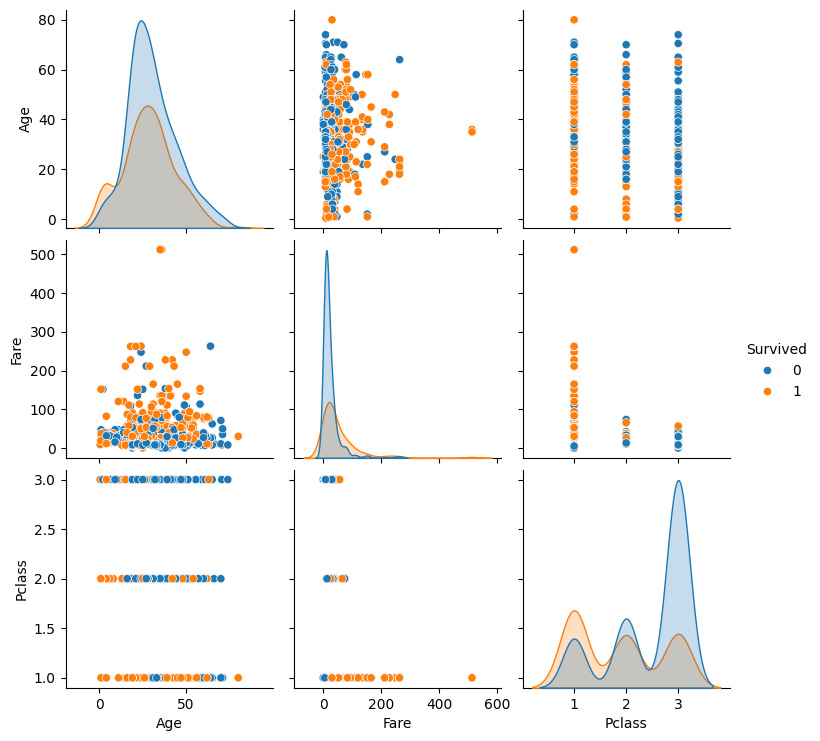

In [34]:
import seaborn as sns
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']].dropna(), hue='Survived')


Графики подтверждают наши предыдущие выводы. Выживаемость зависит от класса (а, соответственно, и от цены билета).

<Axes: >

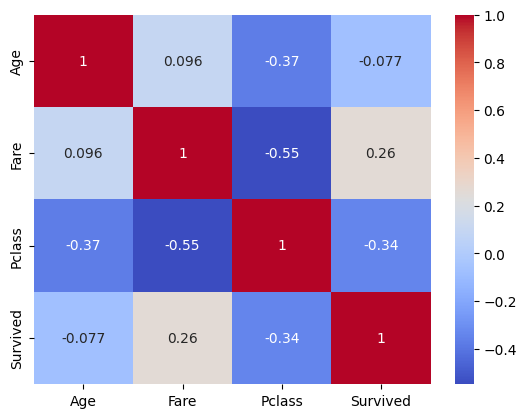

In [35]:
sns.heatmap(df[['Age', 'Fare', 'Pclass', 'Survived']].corr(), annot=True, cmap='coolwarm')

Не сложно заметить, что выживаемость выше всего при высокой стоимости билета

In [36]:
df['Age'].fillna(df['Age'].median())
df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'].fillna("Unknown")


0      Unknown
1          C85
2      Unknown
3         C123
4      Unknown
        ...   
886    Unknown
887        B42
888    Unknown
889       C148
890    Unknown
Name: Cabin, Length: 891, dtype: str

In [37]:
df.dropna(subset = ['Fare'])
df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [38]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['Fare'] >= Q1 - 1.5 * IQR) & (df['Fare'] <= Q3 + 1.5 * IQR)]
print(df_clean)

     PassengerId  Survived  Pclass  \
0              1         0       3   
2              3         1       3   
3              4         1       1   
4              5         0       3   
5              6         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                         Braund, Mr. Owen Harris    male  22.0      1      0   
2                          Heikkinen, Miss. Laina  female  26.0      0      0   
3    Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0   
4                        Allen, Mr. William Henry    male  35.0      0      0   
5                                Moran, Mr. James    male   NaN      0      0   
..                                            ...     ...

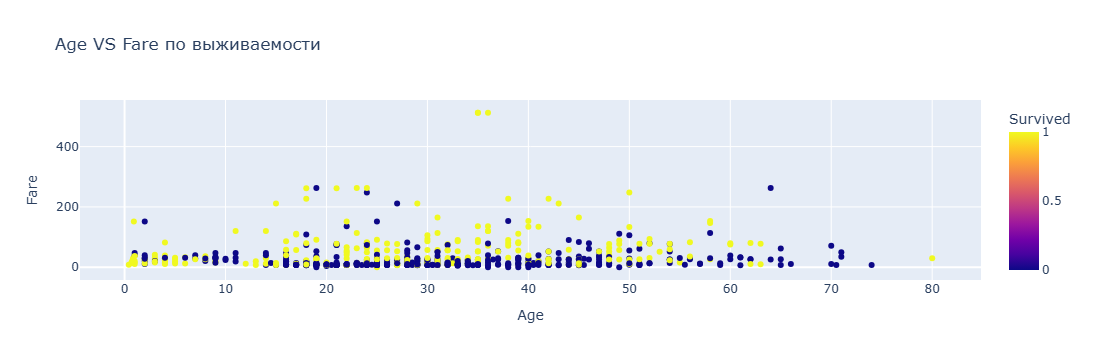

In [39]:
import plotly.express as px
fig = px.scatter(df, x='Age', y='Fare', color='Survived', title='Age VS Fare по выживаемости')
fig.show()

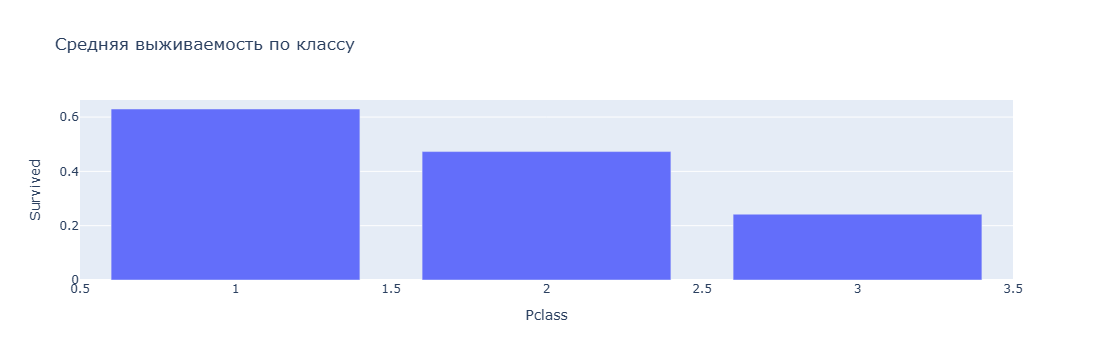

In [40]:
fig = px.bar(df.groupby('Pclass')['Survived'].mean().reset_index(), x='Pclass', y='Survived', title='Средняя выживаемость по классу')
fig.show()

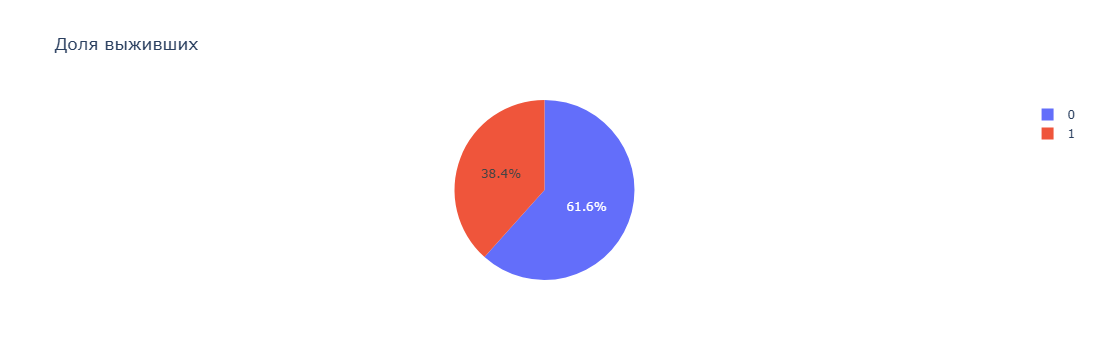

In [41]:
fig = px.pie(df, names='Survived', title='Доля выживших')
fig.show()

Только 38.4% пассажиров на Титанике выжило.